In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/major/abt.parquet')

# input variables: season window, drop rolling, targets, and all away-team columns
def select_features(include_awt=False):
    num = abt.select_dtypes('number').columns
    return [c for c in num
            if 'rolling' not in c and not c.startswith('t_')
            and (include_awt or not c.startswith('awt'))
            and abt[c].nunique() > 1]

features = select_features()
len(features)

89

In [2]:
def group_corr(cols, method='spearman', linkage='average', cut=0.31):
    corr = abt[cols].corr(method=method)
    abscorr = corr.abs().fillna(0)
    dist = 1 - abscorr.to_numpy()
    np.fill_diagonal(dist, 0)

    model = AgglomerativeClustering(metric='precomputed', linkage=linkage,
                                    distance_threshold=cut, n_clusters=None)
    labels = model.fit_predict(dist)

    groups = {}
    for col, lab in zip(cols, labels):
        groups.setdefault(lab, []).append(col)

    def representative(members):
        # the most central member: highest average |corr| with the rest of its group
        return abscorr.loc[members, members].mean().idxmax()

    families = sorted([g for g in groups.values() if len(g) >= 2], key=len, reverse=True)
    reps = [representative(g) for g in families]

    group_corr_matrix = abt[reps].corr(method=method)
    plt.figure(figsize=(len(reps) * 0.65 + 3, len(reps) * 0.55 + 3))
    sns.heatmap(group_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, cbar=False)
    plt.title(f'correlation between group representatives  (cut={cut}, {len(reps)} groups)')
    plt.tight_layout()
    plt.show()

    for members in families:
        rep = representative(members)
        print(rep)
        for col in members:
            if col != rep:
                print('   ', col)
        print()

    singletons = [g[0] for g in groups.values() if len(g) == 1]
    print('singletons:')
    for col in sorted(singletons):
        print('   ', col)

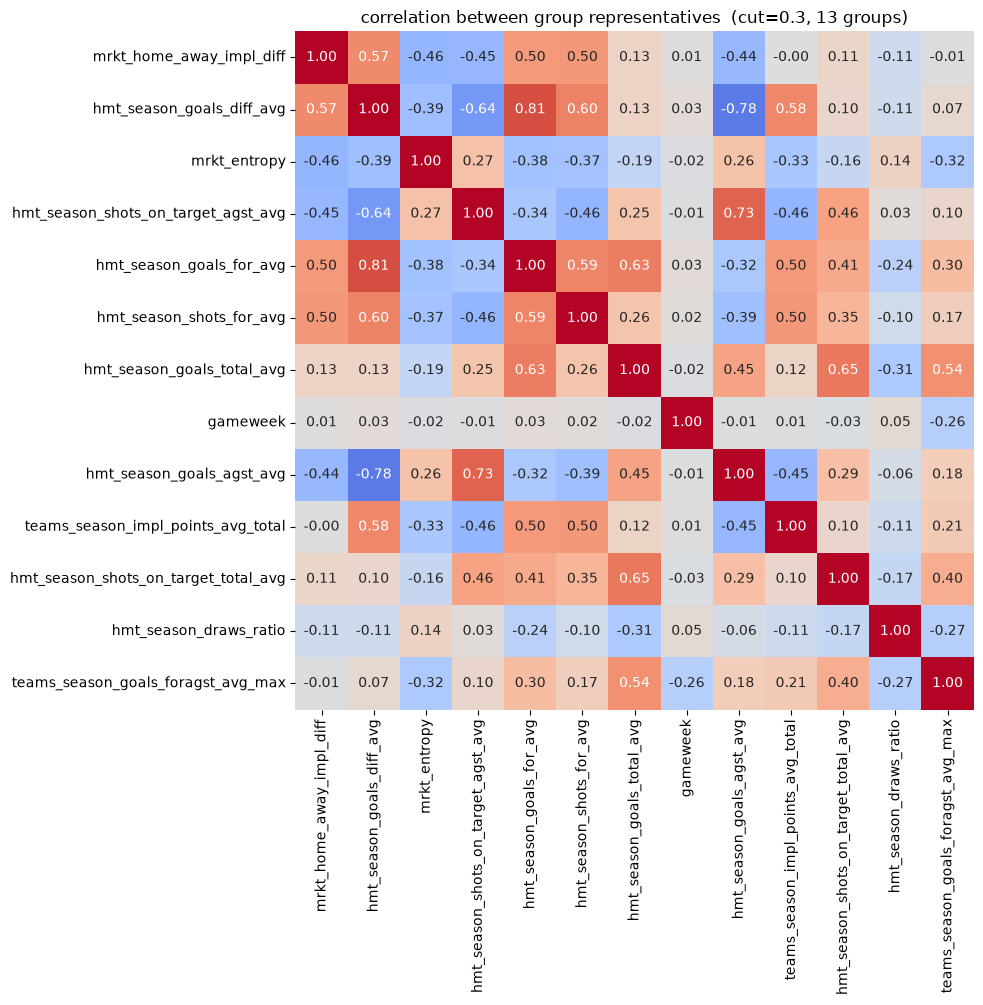

mrkt_home_away_impl_diff
    b365_home_odds
    b365_away_odds
    mrkt_home_odds
    mrkt_away_odds
    b365_home_impl
    b365_away_impl
    mrkt_home_impl
    mrkt_away_impl
    teams_season_goals_diff_avg_diff
    teams_season_shots_on_target_diff_avg_diff
    teams_season_points_avg_diff
    teams_season_impl_points_avg_diff
    teams_elo_diff

hmt_season_goals_diff_avg
    hmt_elo
    hmt_home_season_points_avg
    hmt_home_season_goals_diff_avg
    hmt_season_points_avg
    hmt_season_wins_ratio
    hmt_season_losses_ratio
    hmt_season_impl_win_avg
    hmt_season_impl_loss_avg
    hmt_season_impl_points_avg

mrkt_entropy
    b365_draw_odds
    mrkt_draw_odds
    b365_draw_impl
    mrkt_draw_impl
    b365_entropy
    mrkt_favrt_impl
    mrkt_undrd_impl

hmt_season_shots_on_target_agst_avg
    hmt_season_shots_agst_avg
    hmt_home_season_shots_agst_avg
    hmt_home_season_shots_on_target_agst_avg
    hmt_season_shots_on_target_diff_avg

hmt_season_goals_for_avg
    hmt_home_sea

In [3]:
group_corr(features, cut=0.30)